<a href="https://colab.research.google.com/github/vyakhyaagoyal/aiml_colab_sem-4/blob/main/AIML_LAB_ASS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from collections import deque
def bfs_traversal(graph, start_node):
    visited = []
    queue = deque([start_node])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            for neighbor in graph.get(node, []):
                if neighbor not in visited:
                    queue.append(neighbor)
    return visited
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F']
}
traversal_order = bfs_traversal(graph, 'A')
print("BFS Traversal Order starting from A:", traversal_order)

BFS Traversal Order starting from A: ['A', 'B', 'C', 'D', 'E', 'F']


In [2]:
import heapq


graph = {
    'S': [('A',1), ('B',4)],
    'A': [('C',2)],
    'B': [('C',1)],
    'C': [('G',3)],
    'G': []
}


heuristic = {
    'S':5,
    'A':3,
    'B':4,
    'C':2,
    'G':0
}

def a_star(start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    g_cost = {start:0}
    parent = {start:None}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            path.reverse()
            return path, g_cost[goal]

        for neighbor, cost in graph[current]:
            new_cost = g_cost[current] + cost

            if neighbor not in g_cost or new_cost < g_cost[neighbor]:
                g_cost[neighbor] = new_cost
                f_cost = new_cost + heuristic[neighbor]
                heapq.heappush(open_list, (f_cost, neighbor))
                parent[neighbor] = current

path, cost = a_star('S','G')

print("Optimal Path:", " -> ".join(path))
print("Total Cost:", cost)

Optimal Path: S -> A -> C -> G
Total Cost: 6


Predicted price for 1400 sq ft house: 60.0 lakh


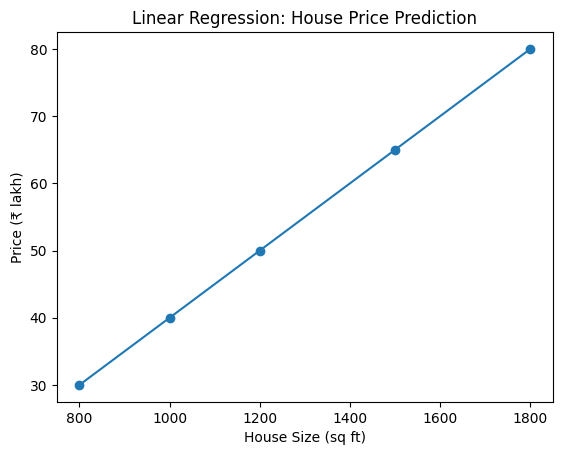

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


size = np.array([800,1000,1200,1500,1800]).reshape(-1,1)
price = np.array([30,40,50,65,80])


model = LinearRegression()
model.fit(size, price)


prediction = model.predict([[1400]])

print("Predicted price for 1400 sq ft house:", prediction[0], "lakh")



plt.scatter(size, price)
plt.plot(size, model.predict(size))
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price (₹ lakh)")
plt.title("Linear Regression: House Price Prediction")

plt.show()